# Exploratory Data Analysis


We'll be trying to predict a classification- survival or deceased.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv('titanic_dataset.csv')

In [4]:
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
data.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


Not a effective way to see null value right so we use somthing different 

we will use seaborn library and we will use heatmap to see which coloum have null values.

<Axes: >

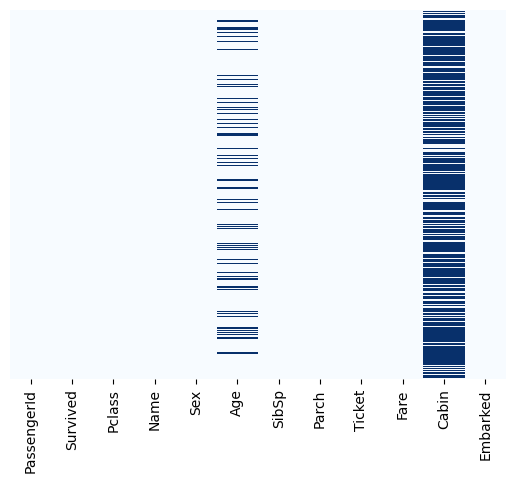

In [6]:
sns.heatmap(data.isnull(),yticklabels=False,cbar=False,cmap='Blues')

#isnull() returns True for missing values and False otherwise.
#Heatmap converts True/False values into colors.
#blue indicates missing values.
#white indicates available data.
#Helps quickly identify columns with missing data.
#Better than viewing raw isnull() output because patterns are visible instantly.



In [7]:
# Calculating the percentage of null value in age column 
print(data['Age'].isnull().sum())
print(len(data))


177
891


In [8]:
(177/891)*100

19.865319865319865

In [9]:
# Calculating the percentage of null value in Cabin column 
print(data['Cabin'].isnull().sum())
print(len(data))

687
891


In [10]:
(687/891)*100

77.10437710437711

In [11]:
'''
Roughly 20 percent of the Age data is missing. The proportion of Age missing is likely small enough for reasonable replacement
with some form of imputation.Looking at the Cabin column, it looks like we are just missing too much of that data to do something useful with at a basic level.
We'll probably drop this later, or change it to another feature like "Cabin known: 1 or 0"

'''

'\nRoughly 20 percent of the Age data is missing. The proportion of Age missing is likely small enough for reasonable replacement\nwith some form of imputation.Looking at the Cabin column, it looks like we are just missing too much of that data to do something useful with at a basic level.\nWe\'ll probably drop this later, or change it to another feature like "Cabin known: 1 or 0"\n\n'

<Axes: xlabel='Survived', ylabel='count'>

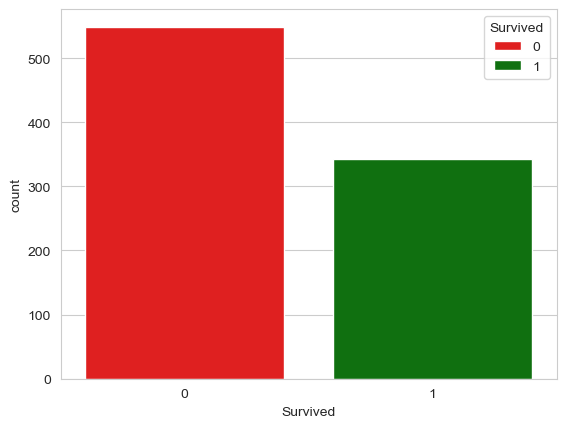

In [12]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',data=data,hue='Survived',palette=['red','green'])

<Axes: xlabel='Survived', ylabel='count'>

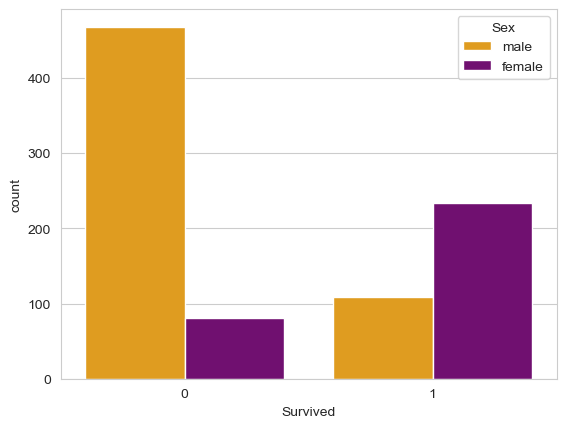

In [13]:
sns.countplot(x='Survived',data=data,hue='Sex',palette=['orange','purple'])

In [14]:
data['Pclass'].unique()

array([3, 1, 2])

<Axes: xlabel='Survived', ylabel='count'>

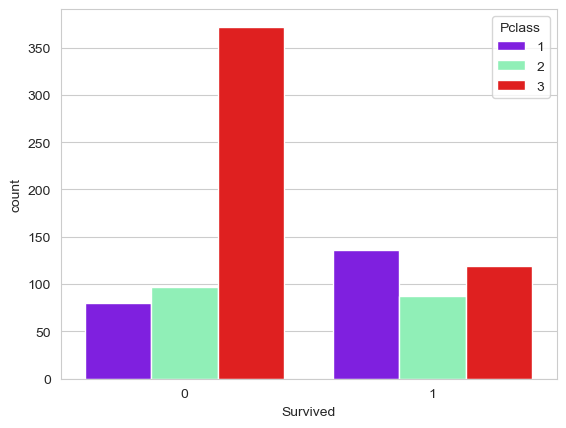

In [15]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',hue='Pclass',data=data,palette='rainbow')

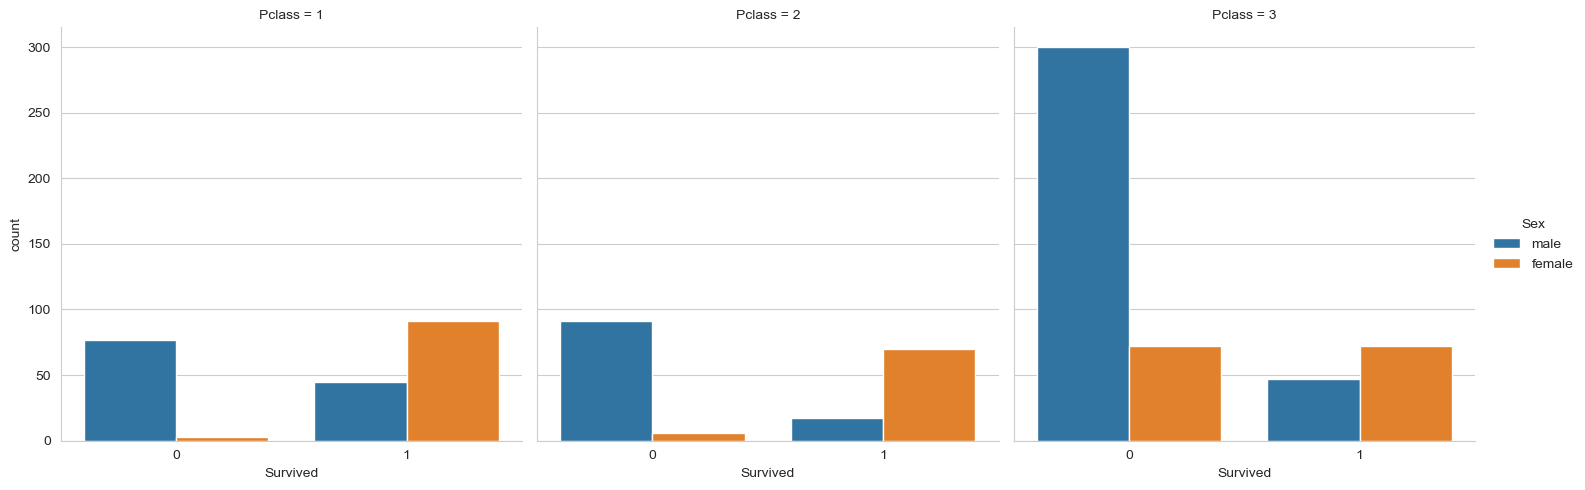

In [16]:
sns.catplot(
    x='Survived',
    hue='Sex',
    col='Pclass',
    data=data,
    kind='count'
)

C:\Users\Harri\AppData\Local\Temp\ipykernel_3540\3107818058.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Age'].dropna(),kde=False,color='darkred',bins=40)


<Axes: xlabel='Age'>

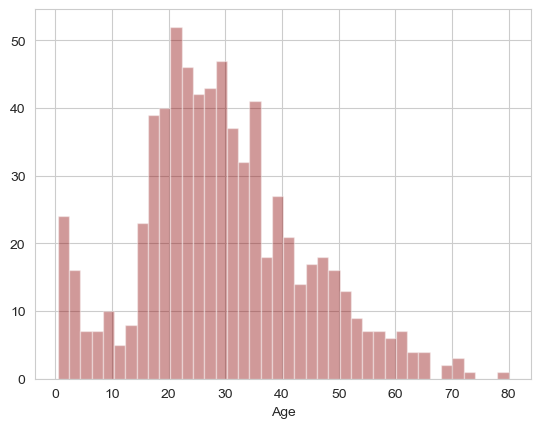

In [17]:
sns.distplot(data['Age'].dropna(),kde=False,color='darkred',bins=40)

<Axes: xlabel='SibSp', ylabel='count'>

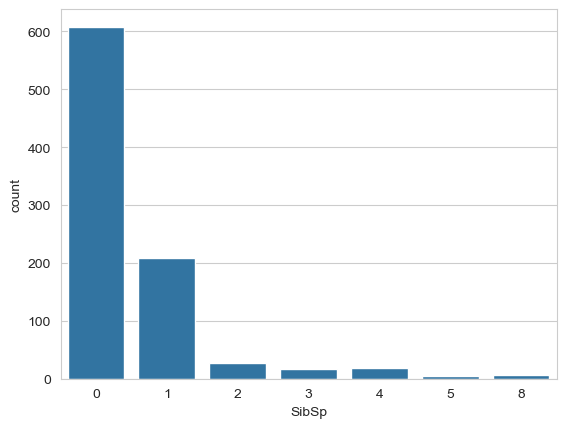

In [18]:
sns.countplot(x='SibSp',data=data)

<Axes: >

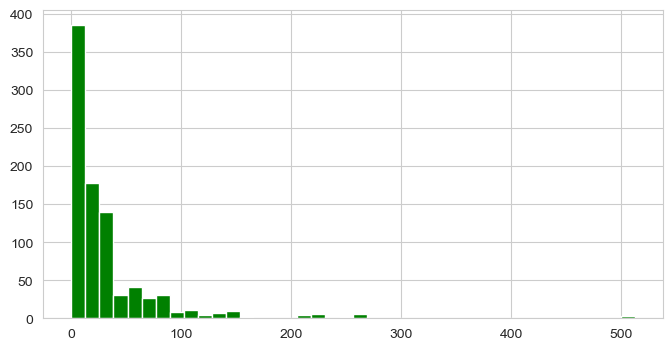

In [19]:
data['Fare'].hist(color='green',bins=40,figsize=(8,4))

# Data cleaning

C:\Users\Harri\AppData\Local\Temp\ipykernel_3540\3462891518.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass',y='Age',data=data,palette='rainbow')


<Axes: xlabel='Pclass', ylabel='Age'>

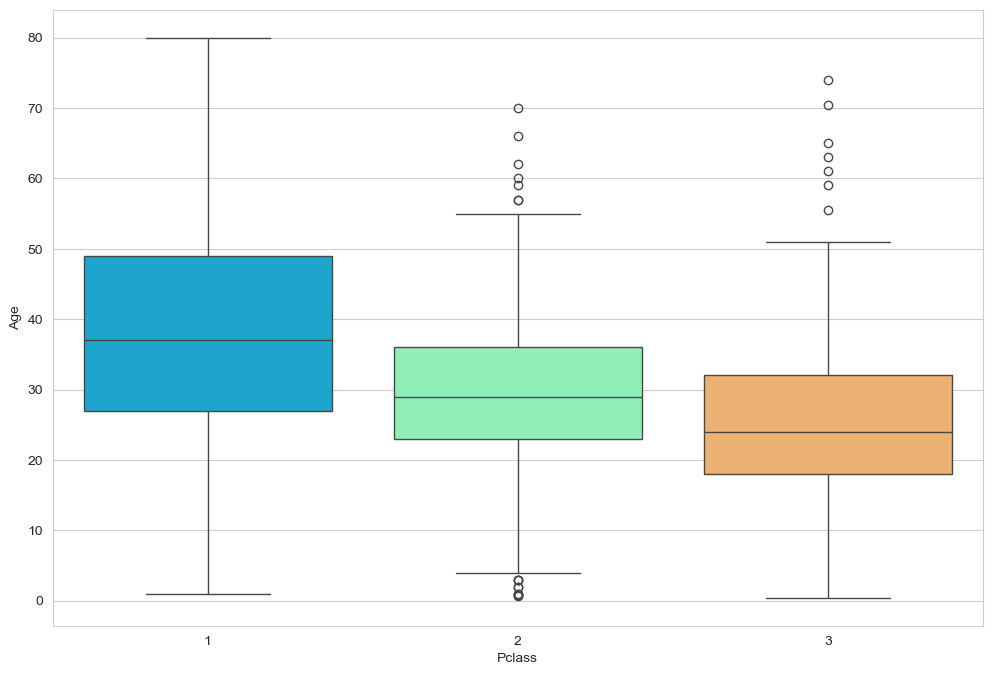

In [20]:
plt.figure(figsize=(12,8))
sns.boxplot(x='Pclass',y='Age',data=data,palette='rainbow')

In [21]:
data.groupby('Pclass')['Age'].median()

Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64

In [22]:
def impute_age(cols):
    Age=cols[0]
    Pclass=cols[1]
    if pd.isnull(Age):
        if Pclass==1:
            return 37
        elif Pclass==2:
            return 29
        else:
            return 24
    else:
        return Age

'''

Notes:
User-defined function to fill missing values in the Age column.
cols[0] contains the Age value.
cols[1] contains the Pclass value.
pd.isnull(Age) checks whether Age is missing (NaN).
If Age is missing:
Pclass 1 → return 37
Pclass 2 → return 29
Pclass 3 → return 24
If Age is not missing, return the original Age.
return sends the calculated age back to apply().

'''

'\n\nNotes:\nUser-defined function to fill missing values in the Age column.\ncols[0] contains the Age value.\ncols[1] contains the Pclass value.\npd.isnull(Age) checks whether Age is missing (NaN).\nIf Age is missing:\nPclass 1 → return 37\nPclass 2 → return 29\nPclass 3 → return 24\nIf Age is not missing, return the original Age.\nreturn sends the calculated age back to apply().\n\n'

In [23]:
data['Age']=data[['Age','Pclass']].apply(impute_age,axis=1)
'''
Notes:
data[['Age','Pclass']] selects the Age and Pclass columns.
apply(impute_age, axis=1) applies the function row by row.
axis=1 means work across columns (row-wise).
For each passenger, Age and Pclass are sent to impute_age().
The function returns an age value for every row.
apply() creates a new Age column using the returned values.
train['Age'] = ... replaces the original Age column with the new one.
Missing Age values are filled based on passenger class.

'''

C:\Users\Harri\AppData\Local\Temp\ipykernel_3540\3078884247.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age=cols[0]
C:\Users\Harri\AppData\Local\Temp\ipykernel_3540\3078884247.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass=cols[1]


"\nNotes:\ndata[['Age','Pclass']] selects the Age and Pclass columns.\napply(impute_age, axis=1) applies the function row by row.\naxis=1 means work across columns (row-wise).\nFor each passenger, Age and Pclass are sent to impute_age().\nThe function returns an age value for every row.\napply() creates a new Age column using the returned values.\ntrain['Age'] = ... replaces the original Age column with the new one.\nMissing Age values are filled based on passenger class.\n\n"

<Axes: >

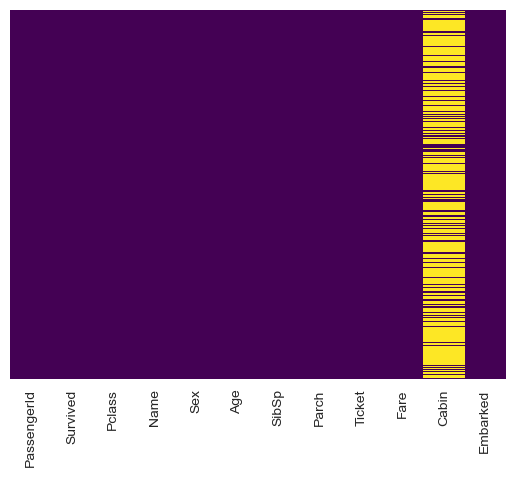

In [24]:
sns.heatmap(data.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [25]:
data.drop('Cabin',axis=1,inplace=True)
'''
Notes:
drop() is used to remove rows or columns from a DataFrame.
'Cabin' is the column name to be removed.
axis=0 → operate on rows.
axis=1 → operate on columns.
Since Cabin is a column, we use axis=1.
inplace=True modifies the original DataFrame directly.
After execution, the Cabin column is permanently removed from train.
'''

"\nNotes:\ndrop() is used to remove rows or columns from a DataFrame.\n'Cabin' is the column name to be removed.\naxis=0 → operate on rows.\naxis=1 → operate on columns.\nSince Cabin is a column, we use axis=1.\ninplace=True modifies the original DataFrame directly.\nAfter execution, the Cabin column is permanently removed from train.\n"

<Axes: >

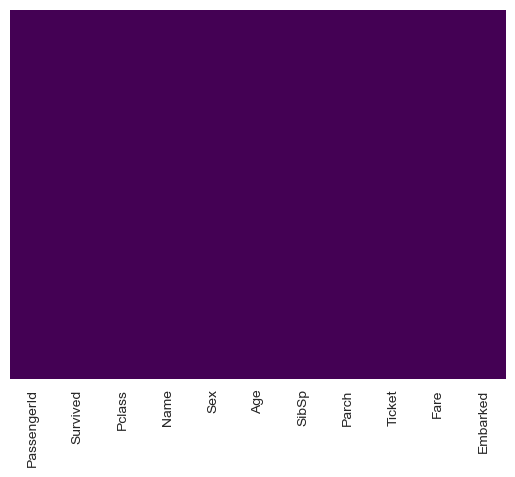

In [26]:
sns.heatmap(data.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [27]:
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


# Converting Categorical Features

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [29]:
'''
Short Note

Converts categorical values into numeric dummy variables.
Creates separate columns for each category.
drop_first=True removes one category to avoid redundant information.
If all dummy columns are 0, the row belongs to the dropped category.
Used because Machine Learning algorithms require numerical input.
'''

pd.get_dummies(data['Embarked'],drop_first=True,dtype=int)

,Q,S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1
...,...,...
886,0,1
887,0,1
888,0,1
889,0,0


In [30]:
pd.get_dummies(data['Sex'],drop_first=True,dtype=int)

,male
0,1
1,0
2,0
3,0
4,1
...,...
886,1
887,0
888,0
889,1


In [31]:
embark=pd.get_dummies(data['Embarked'],drop_first=True,dtype=int)
sex=pd.get_dummies(data['Sex'],drop_first=True,dtype=int)

In [32]:
data.drop(['Sex','Embarked','Name','Ticket'],axis=1,inplace=True)

In [33]:
data.drop(['PassengerId'],axis=1,inplace=True)

In [34]:
data

,Survived,Pclass,Age,SibSp,Parch,Fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000
887,1,1,19.0,0,0,30.0000
888,0,3,24.0,1,2,23.4500
889,1,1,26.0,0,0,30.0000


In [35]:
data=pd.concat([data,sex,embark],axis=1)

In [36]:
data

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1
...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,1,0,1
887,1,1,19.0,0,0,30.0000,0,0,1
888,0,3,24.0,1,2,23.4500,0,0,1
889,1,1,26.0,0,0,30.0000,1,0,0


# Building a Logistic Regression model 

In [37]:
data.drop('Survived',axis=1)

,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,3,22.0,1,0,7.2500,1,0,1
1,1,38.0,1,0,71.2833,0,0,0
2,3,26.0,0,0,7.9250,0,0,1
3,1,35.0,1,0,53.1000,0,0,1
4,3,35.0,0,0,8.0500,1,0,1
...,...,...,...,...,...,...,...,...
886,2,27.0,0,0,13.0000,1,0,1
887,1,19.0,0,0,30.0000,0,0,1
888,3,24.0,1,2,23.4500,0,0,1
889,1,26.0,0,0,30.0000,1,0,0


In [38]:
data['Survived']

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(data.drop('Survived',axis=1),
                                                    data['Survived'],
                                                    test_size=0.30,
                                                    random_state=101)

# Training  and Predicting

machine learning model :- A Machine Learning Model is a mathematical program that learns patterns from training data
and uses those patterns to make predictions on new data.

In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
mymodel= LogisticRegression(max_iter=10000)
mymodel.fit(X_train,y_train)

LogisticRegression(max_iter=10000)

In [43]:
predictions = mymodel.predict(X_test)

In [44]:
from sklearn.metrics import confusion_matrix

In [45]:
c_matrix =confusion_matrix(y_test,predictions)

In [46]:
c_matrix

array([[134,  20],
       [ 38,  76]])

In [47]:
from sklearn.metrics import accuracy_score

In [48]:
accuracy=accuracy_score(y_test,predictions)
accuracy

0.7835820895522388

# The model achieved 78.36% accuracy on the test set.